#### Binary Classification Windows

In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from functools import reduce
from sklearn.base import clone
from sklearn.metrics import f1_score as f1_metric
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')


In [12]:
war_date = pd.to_datetime('2022-02-24')
pre_start = war_date - pd.DateOffset(months=6) 

In [13]:
post_windows = [
    ('post_0-6m', war_date, war_date + pd.DateOffset(months=6)),
    ('post_6-12m', war_date + pd.DateOffset(months=6), war_date + pd.DateOffset(months=12)),
    ('post_12-18m', war_date + pd.DateOffset(months=12), war_date + pd.DateOffset(months=18)),
    ('post_18-24m', war_date + pd.DateOffset(months=18), war_date + pd.DateOffset(months=24)),
    ('post_24-30m', war_date + pd.DateOffset(months=24), war_date + pd.DateOffset(months=30))
]

In [14]:
exclude = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa',
]

In [15]:
min_days_per_period = 30
cv_folds = 10
threshold = 0.8

#### Features

In [16]:
features = [
    # activity sent
    'donor_daily_message_count',
    'donor_daily_avg_length',
    'donor_daily_audio_count',
    'daily_active_chats',
    'donor_daily_active_hours',
    # activity received
    'n_messages_received',
    # ratio
    'words_sent_over_words_received',
    # public activity 
    'donor_daily_post_count',
    'donor_daily_comment_count',
    'donor_daily_reaction_count',
    # temporal patterns
    'night_share',
    'night_share_reactions',
    # social structure
    'frac_words_closest_5_contacts',
]

#### Models

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print(f'Windows: {len(post_windows)}')
for label, start, end in post_windows:
    print(f'  {label}: {start.date()} — {end.date()}')

Windows: 5
  post_0-6m: 2022-02-24 — 2022-08-24
  post_6-12m: 2022-08-24 — 2023-02-24
  post_12-18m: 2023-02-24 — 2023-08-24
  post_18-24m: 2023-08-24 — 2024-02-24
  post_24-30m: 2024-02-24 — 2024-08-24


In [18]:
base = daily_data

dfs_to_load = [
    'donor_daily_message_count.csv',
    'daily_active_chats.csv',
    'donor_daily_audio.csv',
    'donor_daily_posts.csv',
    'donor_daily_time_shares.csv',
    'donor_daily_avg_length.csv',
    'donor_daily_comments.csv',
    'donor_daily_reactions.csv',
    'donor_daily_active_hours.csv',
    'donor_daily_messages_received.csv',
    'donor_daily_words_received.csv',
    'donor_daily_word_count.csv',
    'donor_daily_night_share_reactions.csv',
    'donor_daily_frac_words_top5.csv'
]

loaded = [pd.read_csv(base / f) for f in dfs_to_load]

for d in loaded:
    d['date'] = pd.to_datetime(d['date'])

df_all = reduce(
    lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'),
    loaded
).fillna(0)

df_all['words_sent_over_words_received'] = (
    df_all['donor_daily_word_count'] / (df_all['words_received'] + 1e-9)
)

df_all = df_all[~df_all['donation_id'].isin(exclude)]

missing = [f for f in features if f not in df_all.columns]
if missing:
    print(f'Missed: {missing}')
else:
    print(f'Donors: {df_all["donation_id"].nunique()}')


Donors: 22


In [19]:
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

window_results = []
all_donors = df_all['donation_id'].unique()

for donor_id in all_donors:
    d = df_all[df_all['donation_id'] == donor_id].copy()

    pre_days = d[(d['date'] >= pre_start) & (d['date'] < war_date)].copy()
    pre_days['label'] = 0

    if len(pre_days) < min_days_per_period:
        continue

    for win_label, win_start, win_end in post_windows:
        post_days = d[(d['date'] >= win_start) & (d['date'] < win_end)].copy()
        post_days['label'] = 1

        if len(post_days) < min_days_per_period:
            for model_name in models:
                window_results.append({
                    'donor_id': donor_id,
                    'donor_short': donor_id[:8],
                    'model': model_name,
                    'window': win_label,
                    'accuracy': np.nan,
                    'f1': np.nan,
                    'n_pre': len(pre_days),
                    'n_post': len(post_days),
                })
            continue

        combined = pd.concat([pre_days, post_days]).sample(
            frac=1, random_state=42).reset_index(drop=True)

        X = combined[features].values
        y = combined['label'].values

        for model_name, model in models.items():
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model',  clone(model))
            ])
            acc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
            f1_scores  = cross_val_score(pipe, X, y, cv=cv, scoring='f1')

            window_results.append({
                'donor_id': donor_id,
                'donor_short': donor_id[:8],
                'model': model_name,
                'window': win_label,
                'accuracy': round(acc_scores.mean(), 4),
                'f1': round(f1_scores.mean(), 4),
                'n_pre': len(pre_days),
                'n_post': len(post_days),
            })

win_df = pd.DataFrame(window_results)
window_order = [w[0] for w in post_windows]
win_df['window'] = pd.Categorical(win_df['window'], categories=window_order, ordered=True)

print(f'Donors: {win_df["donor_id"].nunique()}')
print(f'Rows: {len(win_df)}')

Donors: 22
Rows: 440


#### Mean accuracy by each window

In [20]:
mean_by_window = (win_df.groupby(['window', 'model'])['accuracy']
    .mean()
    .groupby('window')
    .agg(['mean', 'std'])
    .round(3)
    .reset_index())
mean_by_window.columns = ['Window', 'Mean accuracy', 'Std']
mean_by_window

,Window,Mean accuracy,Std
0,post_0-6m,0.710,0.008
1,post_6-12m,0.769,0.002
2,post_12-18m,0.785,0.005
3,post_18-24m,0.787,0.003
4,post_24-30m,0.806,0.005


#### Results by each model

In [21]:
summary_table = (
    win_df.groupby(['model', 'window'])[['accuracy', 'f1']]
    .mean()
    .round(3)
    .reset_index()
)

for model_name in models:
    print(f'\n{model_name}')
    display(
        summary_table[summary_table['model'] == model_name]
        [['window', 'accuracy', 'f1']]
        .set_index('window')
    )



Logistic Regression


,accuracy,f1
window,,
post_0-6m,0.715,0.716
post_6-12m,0.769,0.770
post_12-18m,0.783,0.780
post_18-24m,0.785,0.786
post_24-30m,0.802,0.800



Random Forest


,accuracy,f1
window,,
post_0-6m,0.705,0.704
post_6-12m,0.770,0.768
post_12-18m,0.793,0.793
post_18-24m,0.790,0.789
post_24-30m,0.812,0.813



Linear SVM


,accuracy,f1
window,,
post_0-6m,0.718,0.719
post_6-12m,0.771,0.771
post_12-18m,0.782,0.779
post_18-24m,0.783,0.784
post_24-30m,0.802,0.798



Gradient Boosting


,accuracy,f1
window,,
post_0-6m,0.701,0.701
post_6-12m,0.767,0.768
post_12-18m,0.783,0.783
post_18-24m,0.789,0.790
post_24-30m,0.808,0.810


#### Heatmap


In [22]:
best_model_name = (
    win_df.groupby('model')['accuracy']
    .mean()
    .idxmax()
)
print(f'Best model: {best_model_name}')

heatmap_df = win_df[win_df['model'] == best_model_name].pivot_table(
    index='donor_short',
    columns='window',
    values='accuracy'
)[window_order]

heatmap_df = heatmap_df.loc[
    heatmap_df.mean(axis=1).sort_values(ascending=False).index
]

Best model: Random Forest


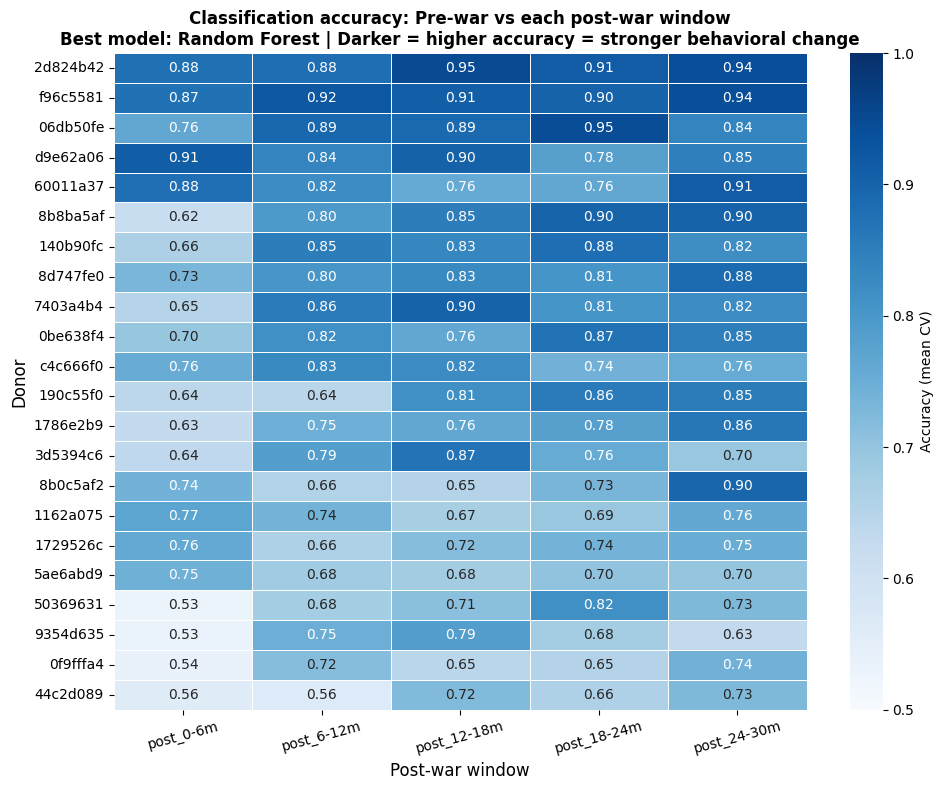

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    heatmap_df,
    cmap='Blues',          
    vmin=0.5, vmax=1.0,    
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Accuracy (mean CV)'}
)

ax.set_xlabel('Post-war window', fontsize=12)
ax.set_ylabel('Donor', fontsize=12)
ax.set_title(
    f'Classification accuracy: Pre-war vs each post-war window\n'
    f'Best model: {best_model_name} | Darker = higher accuracy = stronger behavioral change',
    fontsize=12, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()